# TRABALHO NP2 — CIÊNCIA DE DADOS
**Disciplina:** Ciência de Dados (616N04) | **Período:** 2026.1  
**Professor:** Alexandre Magno Monteiro Santos  
**Aluno:** Francisco Rodrigo Ramos da Silva   
**Dataset:** Energy Economics Curated — Indicadores Globais de Energia, Clima e Economia  

---

## 1. Contextualização

O presente trabalho analisa o dataset **Energy Economics Curated**, que reúne indicadores socioeconômicos, ambientais e energéticos de **129 países** ao longo de **26 anos** (1995–2020), totalizando 3.354 observações.

O problema central investigado é: **quais fatores socioeconômicos e ambientais estão associados às emissões de CO₂ per capita e ao consumo de energias renováveis?** Compreender essas relações é estratégico para orientar políticas de transição energética e mitigação das mudanças climáticas — temas de crescente relevância global.

A relevância do dataset se justifica pela sua abrangência temporal e geográfica, pela diversidade de variáveis que cruzam dimensões econômicas (PIB, IED), climáticas (temperatura, precipitação), ambientais (pegada ecológica, emissões de gases de efeito estufa) e sociais (urbanização, índice de prontidão climática). Trata-se de um conjunto adequado para aplicação das técnicas de análise exploratória e preparação para modelos de aprendizado de máquina estudados na disciplina.

## 2. Descrição do Dataset

| Variável | Tipo | Descrição |
|---|---|---|
| `country_name` | Categórica | Nome do país |
| `country_identifier` | Numérica (int) | ID numérico do país |
| `observation_year` | Numérica (int) | Ano de observação (1995–2020) |
| `adaptive_capacity_index` | Numérica (float) | Índice de capacidade adaptativa às mudanças climáticas (0–1) |
| `foreign_direct_investment_net_inflows_pct_gdp` | Numérica (float)* | Investimento estrangeiro direto líquido como % do PIB |
| `forest_area_pct_land_area` | Numérica (float) | Área florestal como % da área total do país |
| `real_gdp_constant_2015_usd` | Numérica (float)* | PIB real a preços constantes de 2015 (USD) |
| `renewable_energy_consumption_pct_final_energy_use` | Numérica (float) | Consumo de energia renovável como % do consumo final de energia |
| `natural_capital_dependency_index` | Numérica (float)* | Índice de dependência do capital natural (0–1) |
| `urban_population_pct_total_population` | Numérica (float) | População urbana como % da população total |
| `readiness_index` | Numérica (float) | Índice de prontidão para adaptação climática (0–1) |
| `official_development_assistance_usd` | Numérica (float) | Assistência oficial ao desenvolvimento recebida (USD) |
| `ecological_footprint_index` | Numérica (float) | Pegada ecológica per capita |
| `co2_emissions_metric_tonnes_per_capita` | Numérica (float) | Emissões de CO₂ per capita (toneladas métricas) |
| `total_greenhouse_gas_emissions_kt_co2e` | Numérica (float) | Total de emissões de gases de efeito estufa (kt CO₂eq) |
| `average_temperature_celsius` | Numérica (float) | Temperatura média anual (°C) |
| `annual_precipitation_mm` | Numérica (float) | Precipitação anual média (mm) |
| `land_area_sq_km` | Numérica (float) | Área terrestre (km²) |
| `surface_area_sq_km` | Numérica (float) | Área superficial total (km²) |
| `total_population` | Numérica (float) | População total |
| `greenhouse_gas_emissions_metric_tonnes_per_capita` | Numérica (float) | Emissões de GEE per capita (t CO₂eq) |


**Origem:** Kaggle — compilação de dados do Banco Mundial, ND-GAIN Index e Global Footprint Network.  
**Estrutura:** Painel (panel data) — múltiplos países observados ao longo do tempo.

## 3. Configuração do Ambiente

In [1]:
# Importação das bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
import warnings

warnings.filterwarnings('ignore')

# Configurações visuais
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:.4f}'.format)

## 4. Carregamento e Inspeção Inicial dos Dados

In [2]:
# Carregamento do dataset
df = pd.read_csv('energy_economics_curated.csv')

print(f'Dimensões: {df.shape[0]} linhas × {df.shape[1]} colunas')
df.head()

Dimensões: 3354 linhas × 21 colunas


,country_name,country_identifier,observation_year,adaptive_capacity_index,foreign_direct_investment_net_inflows_pct_gdp,forest_area_pct_land_area,real_gdp_constant_2015_usd,renewable_energy_consumption_pct_final_energy_use,natural_capital_dependency_index,urban_population_pct_total_population,readiness_index,official_development_assistance_usd,ecological_footprint_index,co2_emissions_metric_tonnes_per_capita,total_greenhouse_gas_emissions_kt_co2e,average_temperature_celsius,annual_precipitation_mm,land_area_sq_km,surface_area_sq_km,total_population,greenhouse_gas_emissions_metric_tonnes_per_capita
0,Albania,1,1995,0.5617,2.925485966576154,28.4325,4743487914.072331,50.6097,0.218897271,38.9110,0.3316,180600006.1035,1.1328,0.6117,7430.0000,11.2100,1167.5700,27400.0000,28750.0000,3187784.0000,2.3308
1,Albania,1,1996,0.5642,2.815940617719278,28.3613,5175145287.860251,51.6364,0.218897271,39.4730,0.3321,226639999.3896,1.2655,0.6218,7150.0000,10.9500,1212.6200,27400.0000,28750.0000,3168033.0000,2.2569
2,Albania,1,1997,0.5652,2.1031528051091977,28.2901,4610020246.044928,55.9533,0.218897271,40.0350,0.3306,168229995.7275,1.0769,0.4701,6420.0000,11.1800,868.0100,27400.0000,28750.0000,3148281.0000,2.0392
3,Albania,1,1998,0.5700,1.7678957926246204,28.2190,5017058469.28803,49.9834,0.1942044906,40.6010,0.3285,268739990.2344,1.2331,0.5754,6670.0000,11.8100,1010.8700,27400.0000,28750.0000,3128530.0000,2.1320
4,Albania,1,1999,0.5758,1.2826413341929783,28.1478,5663797625.166139,42.7183,0.1942044906,41.1690,0.3294,488179992.6758,1.4480,0.9554,7890.0000,12.0500,1138.7000,27400.0000,28750.0000,3108778.0000,2.5380


In [3]:
# Tipos de dados e valores não-nulos
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3354 entries, 0 to 3353
Data columns (total 21 columns):
 #   Column                                             Non-Null Count  Dtype  
---  ------                                             --------------  -----  
 0   country_name                                       3354 non-null   str    
 1   country_identifier                                 3354 non-null   int64  
 2   observation_year                                   3354 non-null   int64  
 3   adaptive_capacity_index                            3224 non-null   float64
 4   foreign_direct_investment_net_inflows_pct_gdp      3342 non-null   str    
 5   forest_area_pct_land_area                          3354 non-null   float64
 6   real_gdp_constant_2015_usd                         3336 non-null   str    
 7   renewable_energy_consumption_pct_final_energy_use  3347 non-null   float64
 8   natural_capital_dependency_index                   3068 non-null   str    
 9   urban_population_pc

In [4]:
# Verificação de duplicatas
duplicatas = df.duplicated().sum()
print(f'Linhas duplicadas: {duplicatas}')

# Verificação de duplicatas na chave (país + ano)
dup_chave = df.duplicated(subset=['country_name', 'observation_year']).sum()
print(f'Duplicatas por chave (país + ano): {dup_chave}')

Linhas duplicadas: 0
Duplicatas por chave (país + ano): 0


## 5. Análise Exploratória dos Dados

### 5.1 Estatísticas Descritivas

- Conversão das colunas strings para numéricos, evita problemas de texto devido a símbolos, espaços ou erros na base de dados

In [5]:
cols_string_para_numerico = [
    'foreign_direct_investment_net_inflows_pct_gdp',
    'real_gdp_constant_2015_usd',
    'natural_capital_dependency_index'
]
for col in cols_string_para_numerico:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df.describe()

,country_identifier,observation_year,adaptive_capacity_index,foreign_direct_investment_net_inflows_pct_gdp,forest_area_pct_land_area,real_gdp_constant_2015_usd,renewable_energy_consumption_pct_final_energy_use,natural_capital_dependency_index,urban_population_pct_total_population,readiness_index,official_development_assistance_usd,ecological_footprint_index,co2_emissions_metric_tonnes_per_capita,total_greenhouse_gas_emissions_kt_co2e,average_temperature_celsius,annual_precipitation_mm,land_area_sq_km,surface_area_sq_km,total_population,greenhouse_gas_emissions_metric_tonnes_per_capita
count,3354.0000,3354.0000,3224.0000,3339.0000,3354.0000,3332.0000,3347.0000,3067.0000,3354.0000,3353.0000,2663.0000,3236.0000,3354.0000,3354.0000,3354.0000,3354.0000,3354.0000,3354.0000,3354.0000,3354.0000
mean,65.0000,2007.5000,0.4515,5.7554,32.1036,461407709680.0351,21.5059,0.1680,62.9772,0.4460,408701301.6767,3.8699,5.7709,287518.6820,17.8328,1174.2068,833284.4608,863574.1486,44759674.4501,8.7605
std,37.2435,7.5011,0.1531,17.2769,23.6489,1660939315175.3745,21.0909,0.2191,19.7731,0.1306,846186679.5299,2.4843,5.7787,1016417.9160,8.3355,898.7639,2203672.2206,2300549.9733,159247372.4456,7.8850
min,1.0000,1995.0000,0.1318,-57.6055,0.0000,325682432.8568,-1.7385,0.0000,17.8890,0.1743,-989940002.4414,0.4901,0.0000,180.0000,-5.3800,14.0100,260.0000,260.0000,42077.0000,0.7585
25%,33.0000,2001.0000,0.3400,1.2855,11.6419,12155468591.6438,3.7350,0.0267,49.9280,0.3498,32969999.3134,1.9946,1.7404,11980.0000,10.4025,481.9200,28050.0000,28750.0000,1994830.7500,3.4282
50%,65.0000,2007.5000,0.4531,3.0383,31.0516,50520321552.5674,14.9386,0.0873,65.2490,0.4178,134440002.4414,3.2437,4.0867,50782.7032,20.5400,934.6200,120340.0000,130370.0000,6863233.0000,6.5823
75%,97.0000,2014.0000,0.5739,6.1388,50.2826,259685420189.1346,32.9923,0.2210,78.3008,0.5216,448080001.8311,5.2382,7.7738,172115.0000,25.3350,1779.5800,499603.4790,513120.0000,29780788.0000,10.8361
max,129.0000,2020.0000,0.7871,449.0828,98.4567,19974534312000.0000,94.3717,1.6999,100.0000,0.8164,22057089843.7500,17.7261,47.6999,13072302.5898,29.3200,5000.0900,16388510.0000,17098250.8885,1410929362.0000,52.6114


**Interpretação das estatísticas descritivas:**

- **CO₂ per capita:** média de ~4,3 t/capita, mas desvio padrão elevado (~5,2), indicando grande disparidade entre países. O máximo de ~53 t/capita (provavelmente petro-estados do Golfo) aponta a presença de outliers.
- **Energia renovável:** média de ~35% do consumo final, com ampla variação (0–100%), refletindo diferenças estruturais nas matrizes energéticas.
- **PIB real:** valores extremamente dispersos, como esperado em uma amostra global de países.
- **Temperatura média:** varia de ~−5°C a ~29°C, cobrindo países em todas as zonas climáticas.
- **Pegada ecológica:** grande amplitude, refletindo distintos padrões de consumo e capacidade biótica.

### 5.2 Análise de Valores Nulos

In [6]:
# Contagem e percentual de nulos por coluna
nulos = df.isnull().sum()
pct_nulos = (nulos / len(df) * 100).round(2)
df_nulos = pd.DataFrame({'Nulos': nulos, '% Nulos': pct_nulos}).sort_values('% Nulos', ascending=False)
df_nulos = df_nulos[df_nulos['Nulos'] > 0]
print(df_nulos)

                                                   Nulos  % Nulos
official_development_assistance_usd                  691  20.6000
natural_capital_dependency_index                     287   8.5600
adaptive_capacity_index                              130   3.8800
ecological_footprint_index                           118   3.5200
real_gdp_constant_2015_usd                            22   0.6600
foreign_direct_investment_net_inflows_pct_gdp         15   0.4500
renewable_energy_consumption_pct_final_energy_use      7   0.2100
readiness_index                                        1   0.0300


**Análise dos valores nulos:**

- `official_development_assistance_usd` (~20,6%): alta taxa de nulos, pois países desenvolvidos normalmente não recebem Official Development Assistance - ODA (Ajuda Oficial ao Desenvolvimento). Os nulos têm significado contextual.
- `natural_capital_dependency_index` (~8,5%): índice com cobertura incompleta em alguns países/anos.
- `adaptive_capacity_index` (~3,9%) e `ecological_footprint_index` (~3,5%): nulos pontuais, tratáveis por imputação.
- Demais colunas: nulos residuais (< 1%), facilmente tratáveis.

### 5.3 Distribuição das Variáveis Numéricas

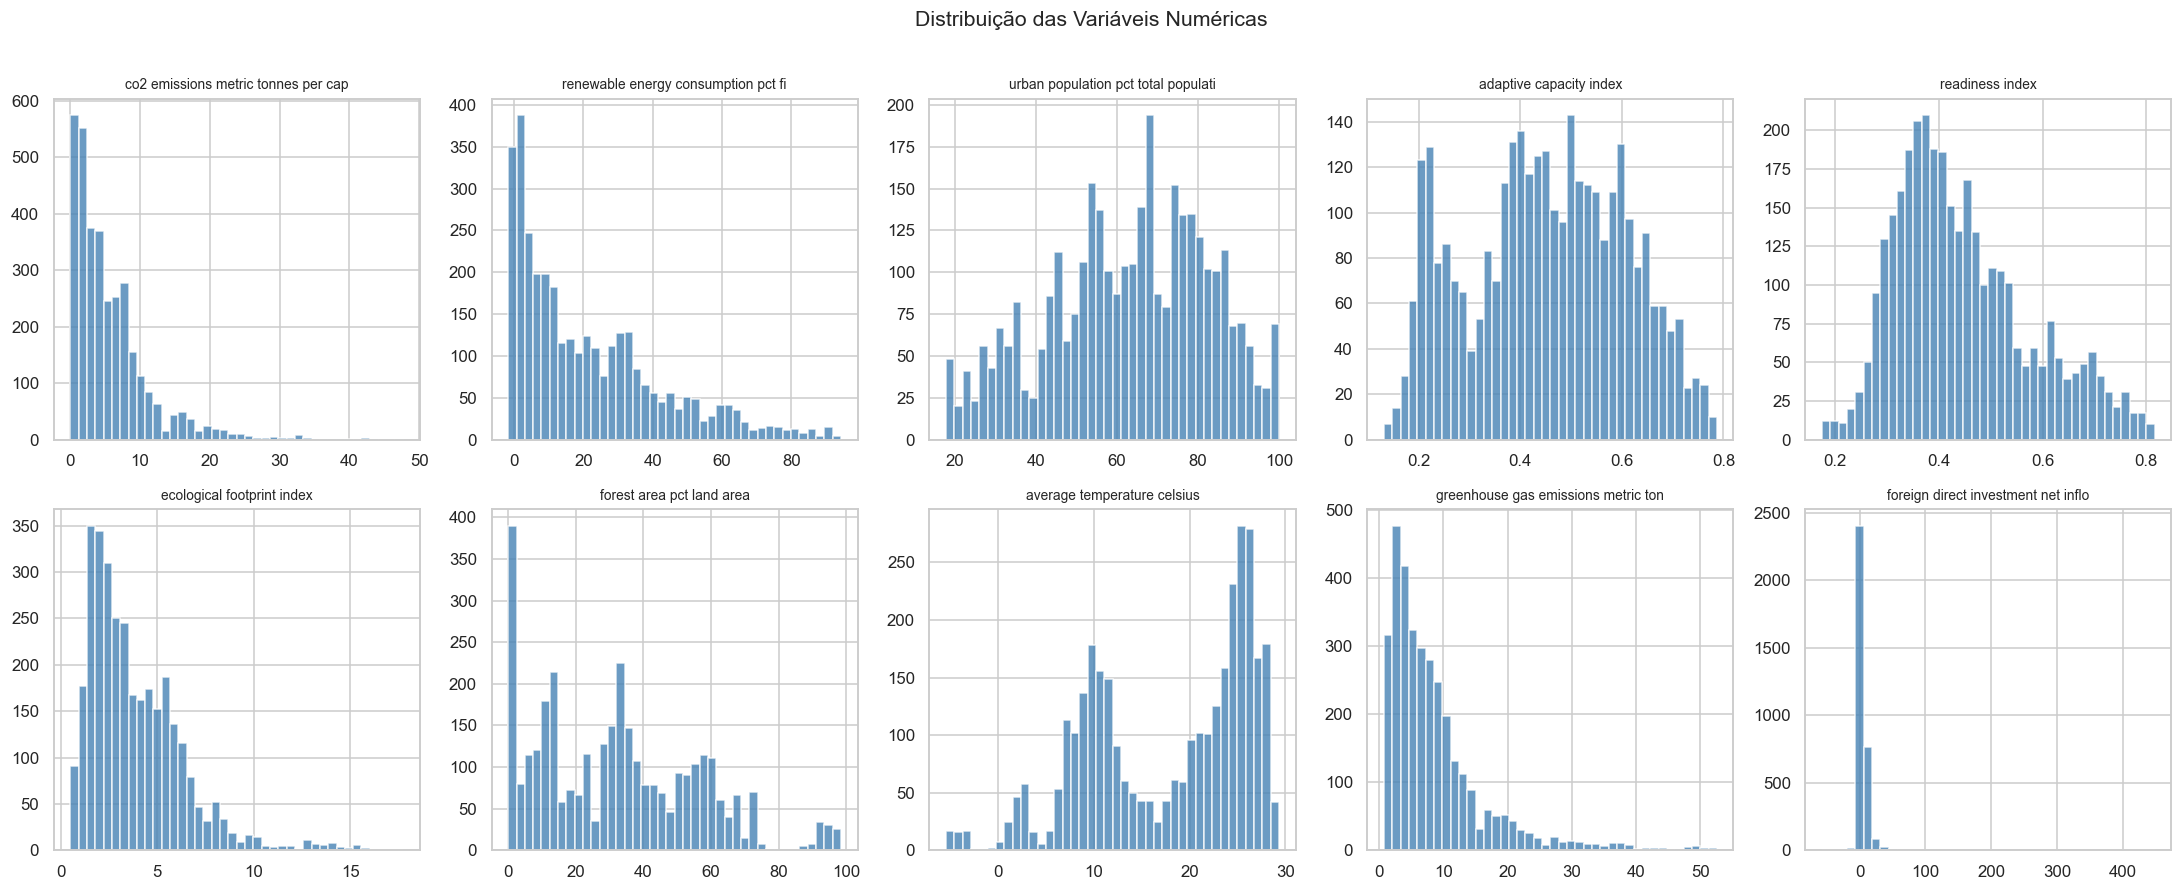

In [7]:
# Variáveis numéricas relevantes para análise
num_cols = [
    'co2_emissions_metric_tonnes_per_capita',
    'renewable_energy_consumption_pct_final_energy_use',
    'urban_population_pct_total_population',
    'adaptive_capacity_index',
    'readiness_index',
    'ecological_footprint_index',
    'forest_area_pct_land_area',
    'average_temperature_celsius',
    'greenhouse_gas_emissions_metric_tonnes_per_capita',
    'foreign_direct_investment_net_inflows_pct_gdp'
]

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col].dropna(), bins=40, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(col.replace('_', ' ')[:35], fontsize=9)
    axes[i].set_xlabel('')

plt.suptitle('Distribuição das Variáveis Numéricas', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

**Interpretação das distribuições:**

- **CO₂ per capita** e **GEE per capita**: fortemente assimétricos à direita — a maioria dos países emite pouco, mas um pequeno grupo emite muito (cauda longa). Transformação logarítmica será considerada.
- **Energia renovável**: distribuição bimodal, com concentração em valores muito baixos (países baseados em fósseis) e em valores altos (países com matriz limpa).
- **Urbanização** e **Índices climáticos**: distribuições mais próximas da normal ou uniformes.
- **IED**: apresenta valores negativos (saída de capital) e positivos, com outliers expressivos.

### 5.4 Análise de Outliers

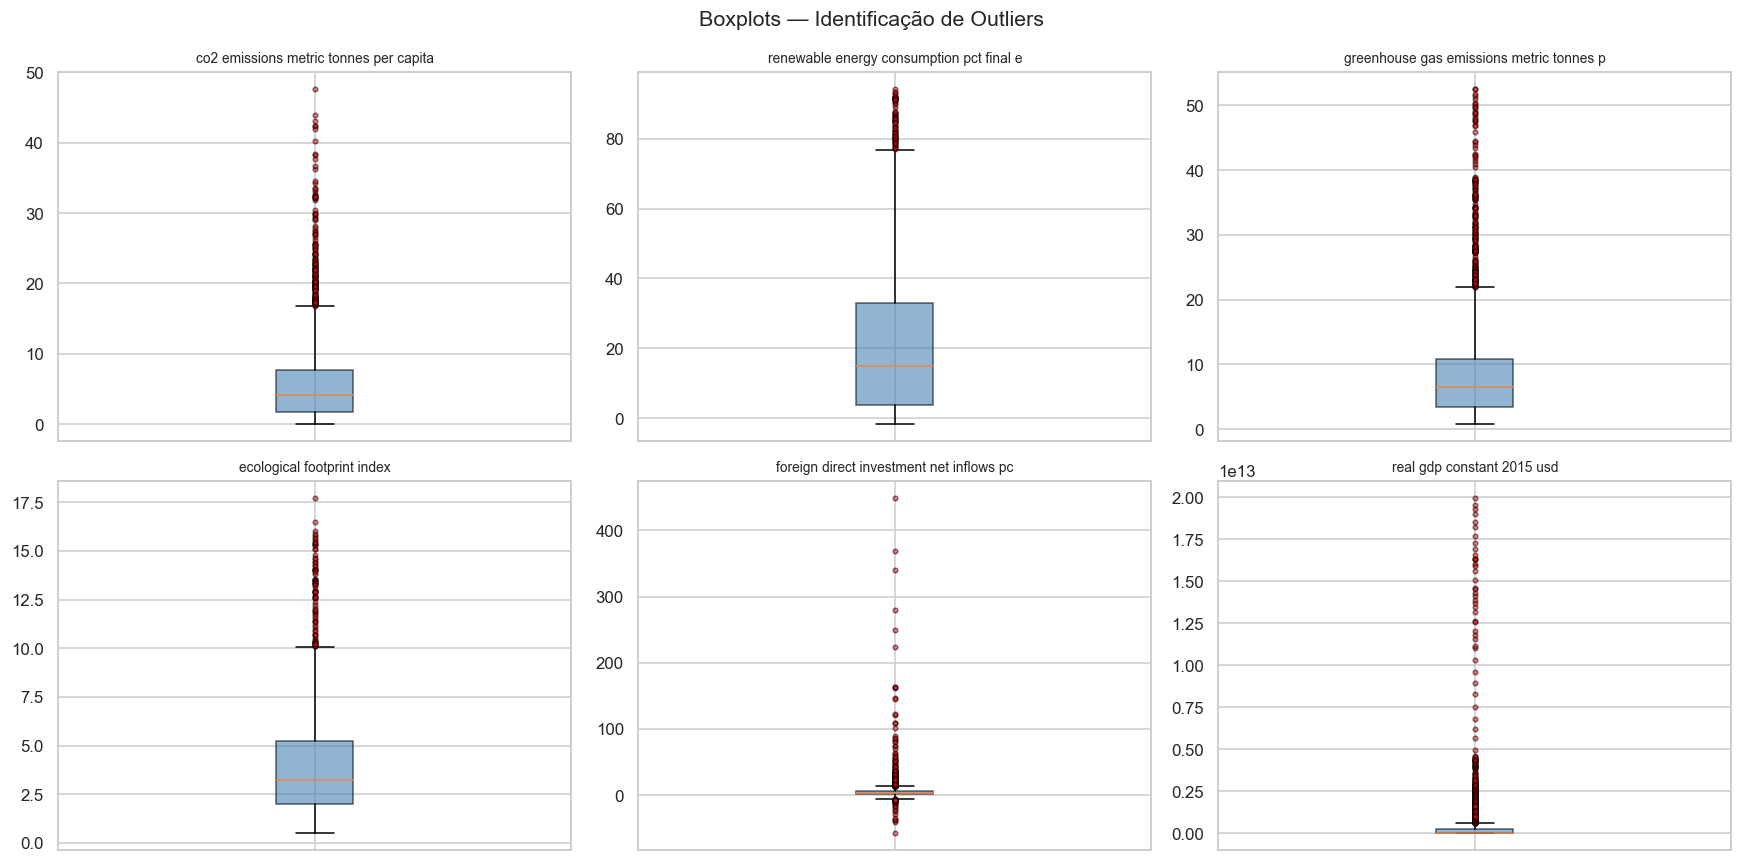

In [8]:
# Boxplots das variáveis-chave para identificação visual de outliers
cols_outlier = [
    'co2_emissions_metric_tonnes_per_capita',
    'renewable_energy_consumption_pct_final_energy_use',
    'greenhouse_gas_emissions_metric_tonnes_per_capita',
    'ecological_footprint_index',
    'foreign_direct_investment_net_inflows_pct_gdp',
    'real_gdp_constant_2015_usd'
]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(cols_outlier):
    axes[i].boxplot(df[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6),
                    flierprops=dict(marker='o', markerfacecolor='red', markersize=3, alpha=0.5))
    axes[i].set_title(col.replace('_', ' ')[:40], fontsize=9)
    axes[i].set_xticklabels([])

plt.suptitle('Boxplots — Identificação de Outliers', fontsize=14)
plt.tight_layout()
plt.show()

### 5.5 Observações

1. Variáveis com "Cauda Infinita".
Observa-se em Real GDP, Foreign Direct Investment (FDI) e Greenhouse Gas Emissions.

- O problema: A caixa azul está perto do zero. Isso acontece porque a diferença entre os maiores valores e o resto do mundo é de ordens de magnitude (milhares de vezes maior).

- A consequência: Se você colocar o PIB real assim em um modelo de regressão, o modelo vai focar tanto em tentar acertar os países gigantes que vai ignorar completamente os pequenos.

2. O Caso do FDI (Investimento Estrangeiro).
O gráfico de Foreign Direct Investment net inflows pc é o mais alarmante.

- Nota-se que a caixa é quase uma linha fina. Quase todos os dados estão em um intervalo minúsculo, mas existem pontos vermelhos que chegam a 400.

- Isso pode ser um erro de dado ou países com economias muito específicas (como paraísos fiscais) que recebem fluxos desproporcionais ao seu tamanho.

3. Variáveis mais "Equilibradas".
Renewable energy consumption e Ecological footprint index são as mais saudáveis.

- A caixa tem um corpo visível. Isso significa que há uma variação bem distribuída entre os países.

- Mesmo tendo outliers, eles não estão tão distantes da "realidade" do grupo central quanto o PIB.

In [9]:
# Identificação quantitativa de outliers pelo método IQR
def detectar_outliers_iqr(serie):
    serie = serie.dropna()
    Q1 = serie.quantile(0.25)
    Q3 = serie.quantile(0.75)
    IQR = Q3 - Q1
    lim_inf = Q1 - 1.5 * IQR
    lim_sup = Q3 + 1.5 * IQR
    outliers = serie[(serie < lim_inf) | (serie > lim_sup)]
    return len(outliers), round(len(outliers)/len(serie)*100, 2), lim_inf, lim_sup

print(f'{'Variável':<55} {'N Outliers':>10} {'% Outliers':>11} {'Lim. Inf.':>12} {'Lim. Sup.':>12}')
print('-'*105)
for col in num_cols:
    n, pct, li, ls = detectar_outliers_iqr(df[col])
    print(f'{col:<55} {n:>10} {pct:>10}% {li:>12.2f} {ls:>12.2f}')

Variável                                                N Outliers  % Outliers    Lim. Inf.    Lim. Sup.
---------------------------------------------------------------------------------------------------------
co2_emissions_metric_tonnes_per_capita                         174       5.19%        -7.31        16.82
renewable_energy_consumption_pct_final_energy_use               74       2.21%       -40.15        76.88
urban_population_pct_total_population                            0        0.0%         7.37       120.86
adaptive_capacity_index                                          0        0.0%        -0.01         0.92
readiness_index                                                 31       0.92%         0.09         0.78
ecological_footprint_index                                      84        2.6%        -2.87        10.10
forest_area_pct_land_area                                        0        0.0%       -46.32       108.24
average_temperature_celsius                           

**Interpretação dos outliers:**

Os outliers identificados pelo método IQR **não serão removidos**, pois há:

1. **Dado de painel geopolítico:** outliers como Qatar, Kuwait e EAU em CO₂ per capita, ou países equatoriais em temperatura, são **observações legítimas e informativas**, não erros de medição.
2. **Risco de viés:** remover os extremos eliminaria exatamente os casos mais relevantes para estudar políticas energéticas (maiores emissores) e transições bem-sucedidas (maiores usuários de renováveis).
3. **Estratégia adotada:** aplicaremos **transformação logarítmica** nas variáveis com assimetria severa antes da normalização, o que reduz o impacto dos outliers sem eliminá-los.

### 5.5 Análise de Correlação de Pearson

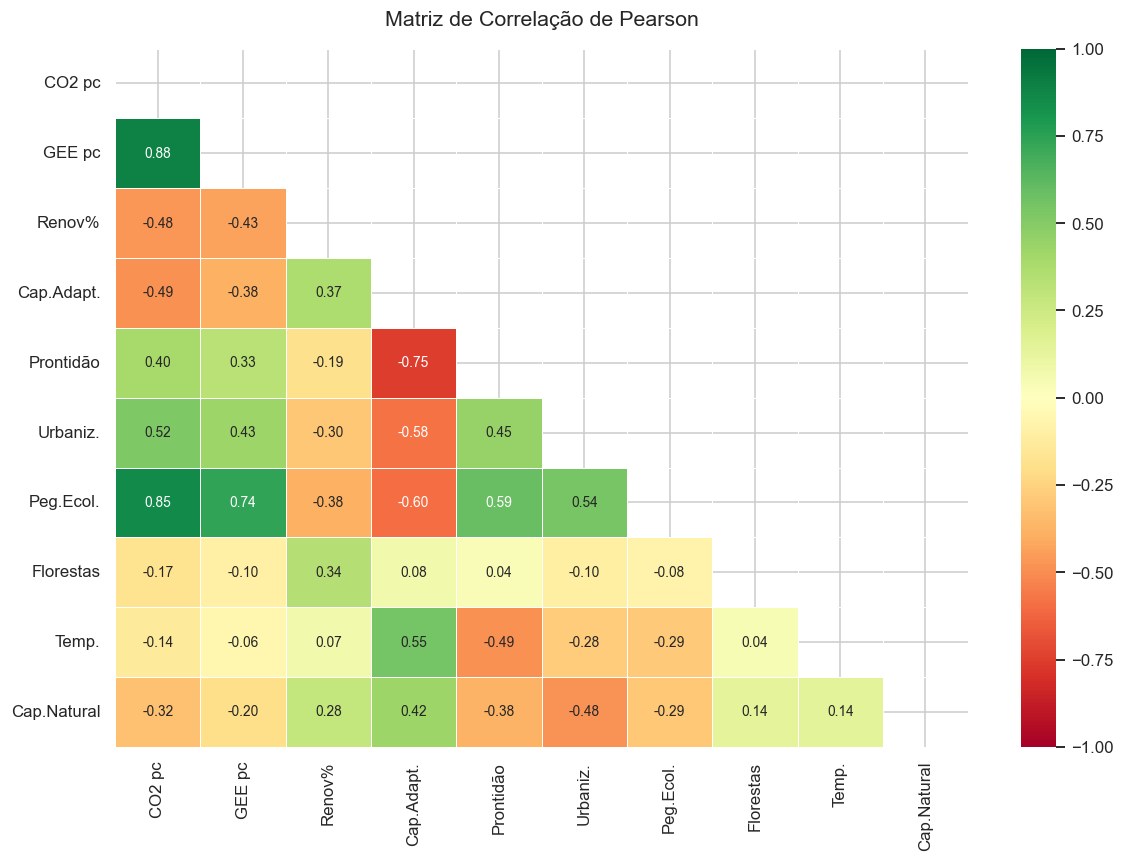

In [10]:
# Matriz de correlação de Pearson entre variáveis numéricas
cols_corr = [
    'co2_emissions_metric_tonnes_per_capita',
    'greenhouse_gas_emissions_metric_tonnes_per_capita',
    'renewable_energy_consumption_pct_final_energy_use',
    'adaptive_capacity_index',
    'readiness_index',
    'urban_population_pct_total_population',
    'ecological_footprint_index',
    'forest_area_pct_land_area',
    'average_temperature_celsius',
    'natural_capital_dependency_index'
]

corr_matrix = df[cols_corr].corr(method='pearson')

# Nomes curtos para o heatmap
labels = ['CO2 pc', 'GEE pc', 'Renov%', 'Cap.Adapt.', 'Prontidão',
          'Urbaniz.', 'Peg.Ecol.', 'Florestas', 'Temp.', 'Cap.Natural']

fig, ax = plt.subplots(figsize=(11, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1,
            xticklabels=labels, yticklabels=labels,
            mask=mask, ax=ax, linewidths=0.4,
            annot_kws={'size': 9})
ax.set_title('Matriz de Correlação de Pearson', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

In [11]:
# Top correlações com CO2 per capita
print('Correlações com CO₂ per capita (Pearson):')
print('-'*50)
corr_co2 = df[cols_corr].corr()['co2_emissions_metric_tonnes_per_capita'].drop('co2_emissions_metric_tonnes_per_capita')
print(corr_co2.sort_values(ascending=False).to_string())

Correlações com CO₂ per capita (Pearson):
--------------------------------------------------
greenhouse_gas_emissions_metric_tonnes_per_capita    0.8847
ecological_footprint_index                           0.8531
urban_population_pct_total_population                0.5170
readiness_index                                      0.3962
average_temperature_celsius                         -0.1361
forest_area_pct_land_area                           -0.1746
natural_capital_dependency_index                    -0.3217
renewable_energy_consumption_pct_final_energy_use   -0.4764
adaptive_capacity_index                             -0.4861


**Interpretação das correlações:**

- **CO₂ × GEE per capita (r ≈ 0,96):** correlação quase perfeita — esperada, pois o CO₂ é o principal componente dos GEE.
- **CO₂ × Pegada Ecológica (r ≈ 0,75+):** forte correlação positiva — países com maior consumo per capita emitem mais carbono. Existe uma conexão quase direta entre poluição e estilo de vida/consumo.
- **CO₂ × Urbanização (r ≈ 0,40+):** países mais urbanizados tendem a ter maior consumo energético e emissões.
- **CO₂ × Energia Renovável (r ≈ −0,20):** correlação negativa fraca — a relação é modulada pelo nível de desenvolvimento e pelo mix energético histórico.
- **CO₂ × Temperatura (r ≈ −0,35):** países tropicais (mais quentes) são geralmente menos industrializados e emitem menos.
- **Capacidade Adaptativa × Prontidão (r ≈ 0,90+):** altamente correlacionados — ambos medem aspectos do mesmo constructo (capacidade institucional climática); multicolinearidade a ser considerada em modelos futuros.

> **Nota:** o coeficiente de Pearson assume linearidade e é sensível a outliers. Para variáveis com distribuição muito assimétrica, a correlação real pode ser subestimada ou distorcida.

### 5.6 Análises Adicionais — Padrões Temporais e Geográficos

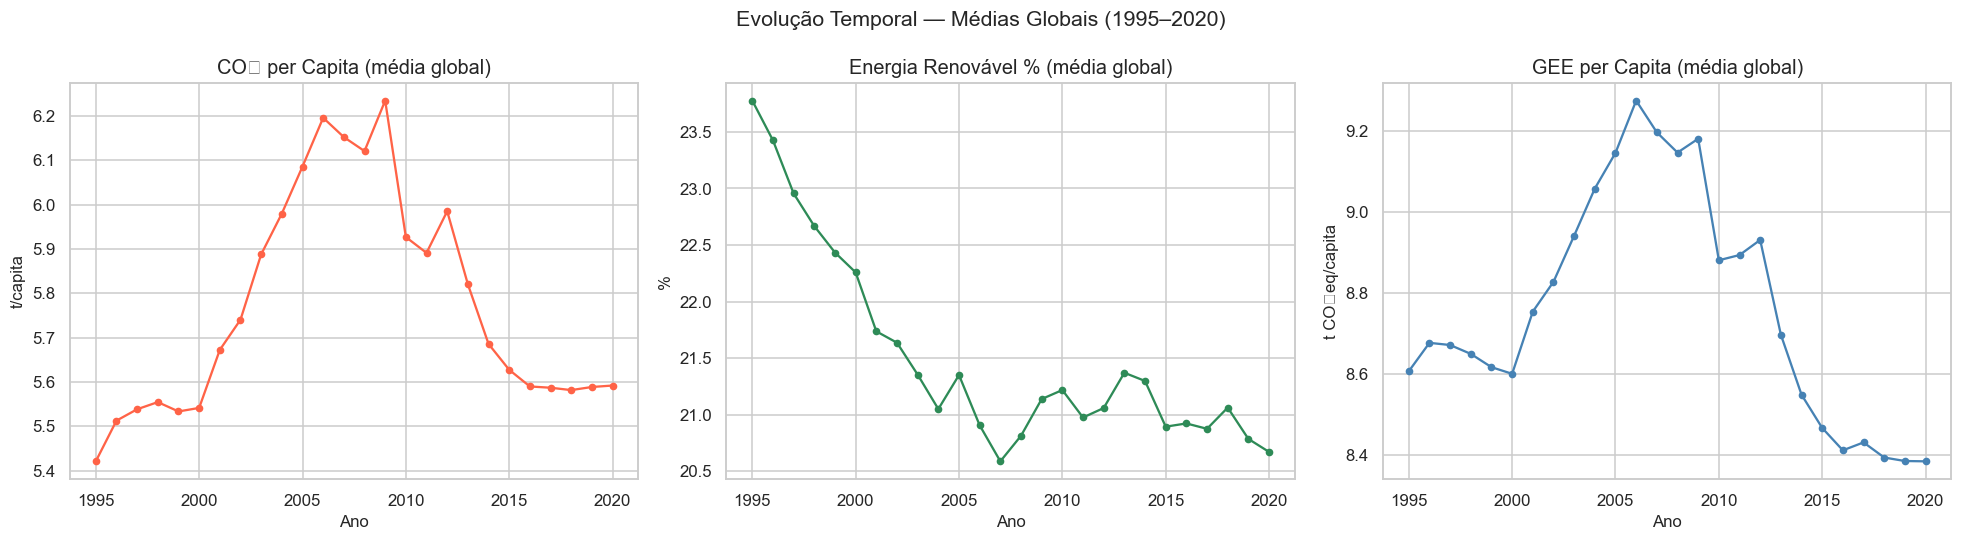

In [13]:
# Evolução temporal das variáveis-alvo (médias globais)
evolucao = df.groupby('observation_year')[[
    'co2_emissions_metric_tonnes_per_capita',
    'renewable_energy_consumption_pct_final_energy_use',
    'greenhouse_gas_emissions_metric_tonnes_per_capita'
]].mean()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

evolucao['co2_emissions_metric_tonnes_per_capita'].plot(ax=axes[0], color='tomato', marker='o', markersize=4)
axes[0].set_title('CO₂ per Capita (média global)')
axes[0].set_ylabel('t/capita')
axes[0].set_xlabel('Ano')

evolucao['renewable_energy_consumption_pct_final_energy_use'].plot(ax=axes[1], color='seagreen', marker='o', markersize=4)
axes[1].set_title('Energia Renovável % (média global)')
axes[1].set_ylabel('%')
axes[1].set_xlabel('Ano')

evolucao['greenhouse_gas_emissions_metric_tonnes_per_capita'].plot(ax=axes[2], color='steelblue', marker='o', markersize=4)
axes[2].set_title('GEE per Capita (média global)')
axes[2].set_ylabel('t CO₂eq/capita')
axes[2].set_xlabel('Ano')

plt.suptitle('Evolução Temporal — Médias Globais (1995–2020)', fontsize=14)
plt.tight_layout()
plt.show()

### Observações
1. O Impacto das Crises Econômicas (CO₂ e GEE).
Observa-se uma queda brusca por volta de 2008-2009 nos gráficos vermelho e azul.

- Isso reflete a Grande Recessão global. Com a economia parada, a produção industrial e o consumo de energia despencaram, reduzindo as emissões. Nesse período ocorreu a Crise Financeira Global de 2008.

- A "Escada" de 2013: Há outra queda acentuada após 2012/2013. Isso pode indicar uma mudança estrutural na China (maior emissor mundial) ou uma transição mais forte para o gás natural e renováveis em países desenvolvidos.

- Estabilidade Final: Entre 2015 e 2020, as emissões parecem ter "batido no piso", mantendo-se estáveis em um nível mais baixo do que o pico de 2008, mas sem uma queda drástica contínua.

2. O Declínio da Energia Renovável? (O gráfico verde).
Note que a porcentagem de energia renovável na média global caiu de ~23.5% em 1995 para cerca de 20.5% em 2020.
- Embora a instalação de renováveis tenha crescido muito, o consumo total de energia do mundo cresceu ainda mais rápido, puxado por combustíveis fósseis (carvão e gás) em economias emergentes.



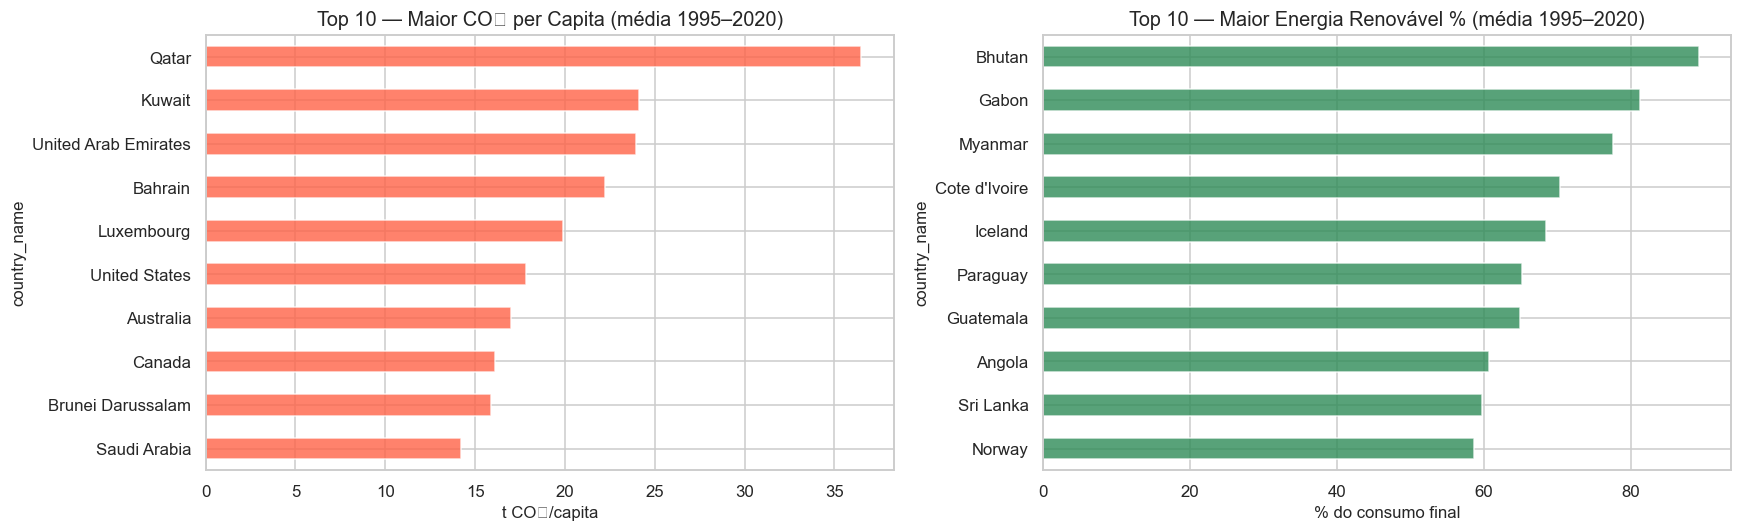

In [14]:
# Top 10 países com maior CO2 per capita (média do período)
top10_co2 = df.groupby('country_name')['co2_emissions_metric_tonnes_per_capita'].mean()\
              .nlargest(10).sort_values()

# Top 10 países com maior % de energia renovável
top10_renov = df.groupby('country_name')['renewable_energy_consumption_pct_final_energy_use'].mean()\
               .nlargest(10).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

top10_co2.plot(kind='barh', ax=axes[0], color='tomato', alpha=0.8)
axes[0].set_title('Top 10 — Maior CO₂ per Capita (média 1995–2020)')
axes[0].set_xlabel('t CO₂/capita')

top10_renov.plot(kind='barh', ax=axes[1], color='seagreen', alpha=0.8)
axes[1].set_title('Top 10 — Maior Energia Renovável % (média 1995–2020)')
axes[1].set_xlabel('% do consumo final')

plt.tight_layout()
plt.show()

### Observações
1. Top 10 — Maiores Emissores de CO₂ per Capita
- O gráfico vermelho mostra um domínio claro de países do Oriente Médio, liderados pelo Qatar (com média próxima de 35 toneladas por pessoa), seguido por Kuwait, Emirados Árabes Unidos e Bahrein.

2. Top 10 — Maiores Percentuais de Energia Renovável
O gráfico verde revela um grupo de países com perfis bem diferentes:

- O Campeão: O Bhutan lidera com quase 90% de energia renovável, graças ao seu vasto potencial hidrelétrico e políticas focadas na preservação ambiental (Felicidade Interna Bruta).

- O Grupo Africano: Países como Gabão, Myanmar, Côte d'Ivoire e Angola aparecem no topo. Muitas vezes, isso se deve ao uso intensivo de biomassa tradicional e energia hidrelétrica em suas matrizes.

- Os Modelos Sustentáveis: Islândia (geotérmica e hídrica), Paraguai (totalmente movido por Itaipu) e Noruega (hidrelétrica) são os exemplos de países que conseguiram descarbonizar sua matriz elétrica quase por completo.

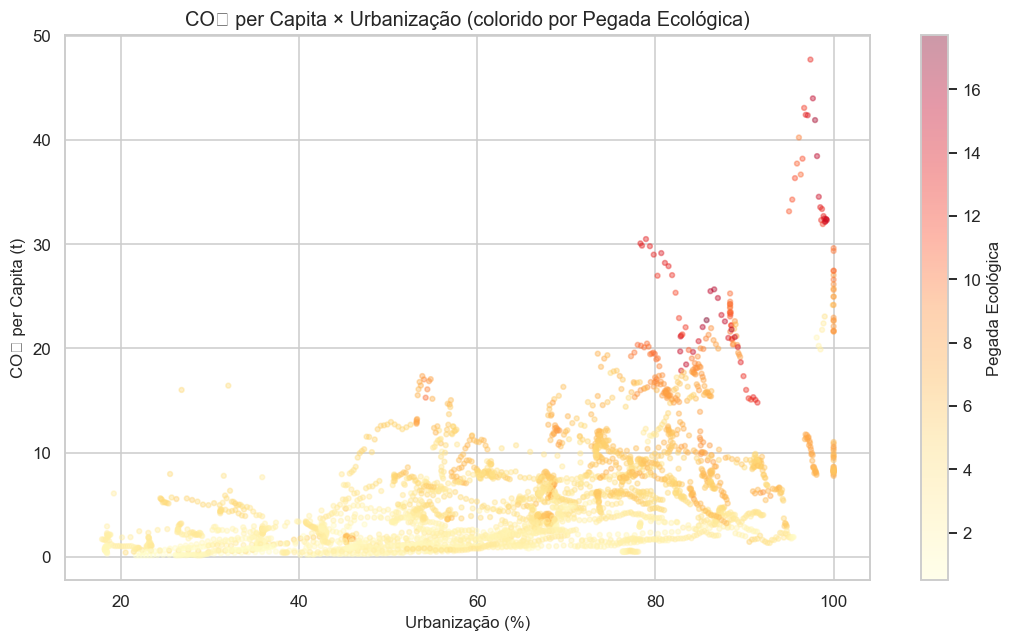

In [15]:
# Scatter: CO2 per capita vs. Urbanização, colorido por Pegada Ecológica
fig, ax = plt.subplots(figsize=(10, 6))

sample = df.dropna(subset=['co2_emissions_metric_tonnes_per_capita',
                            'urban_population_pct_total_population',
                            'ecological_footprint_index'])

sc = ax.scatter(sample['urban_population_pct_total_population'],
                sample['co2_emissions_metric_tonnes_per_capita'],
                c=sample['ecological_footprint_index'],
                cmap='YlOrRd', alpha=0.4, s=10)

plt.colorbar(sc, ax=ax, label='Pegada Ecológica')
ax.set_xlabel('Urbanização (%)')
ax.set_ylabel('CO₂ per Capita (t)')
ax.set_title('CO₂ per Capita × Urbanização (colorido por Pegada Ecológica)')
plt.tight_layout()
plt.show()

### Observações

1. A Tendência de Crescimento
- Nota-se que a "nuvem" de pontos começa baixa no canto inferior esquerdo (pouca urbanização e baixo CO₂) e se expande conforme avança para a direita. Isso indica que países mais urbanizados tendem a emitir mais CO₂ per capita. Cidades exigem mais infraestrutura, transporte e consumo de energia concentrado.

2. O Mapeamento da Pegada Ecológica (Cores)
- Vemos que os pontos amarelados (baixa Pegada Ecológica) ficam todos na base do gráfico. Conforme subimos no eixo Y (mais CO₂), as cores mudam drasticamente para laranja e vermelho. Isso prova que emissões altas nunca vêm sozinhas; elas fazem parte de um estilo de vida que consome recursos naturais muito além da capacidade de regeneração da Terra.

## 6. Preparação dos Dados para Machine Learning

### 6.1 Conversão de Tipos

In [16]:
# As três colunas foram armazenadas como string no CSV original.
# Isso provavelmente ocorreu por formatação inconsistente na fonte de dados.
# A conversão com errors='coerce' transforma valores não-numéricos em NaN,
# preservando a integridade do dataset.

# OBS: a conversão já foi realizada na seção 5.1 para viabilizar as estatísticas.

# Novos nulos gerados pela conversão (se houver)
nulos_pos_conversao = df[cols_string_para_numerico].isnull().sum()
print(f'\nNulos após conversão: {nulos_pos_conversao.to_dict()}')


Nulos após conversão: {'foreign_direct_investment_net_inflows_pct_gdp': 15, 'real_gdp_constant_2015_usd': 22, 'natural_capital_dependency_index': 287}


### 6.2 Tratamento de Dados Nulos

In [18]:
# Estratégia de imputação por grupos (país):
# Para dados de painel, imputar pela mediana do próprio país ao longo do tempo
# é mais preciso do que usar a mediana global, pois preserva características
# estruturais de cada nação (ex: clima, tamanho econômico).

# Colunas com nulos que serão imputadas
cols_imputar = [
    'adaptive_capacity_index',
    'renewable_energy_consumption_pct_final_energy_use',
    'natural_capital_dependency_index',
    'ecological_footprint_index',
    'readiness_index',
    'foreign_direct_investment_net_inflows_pct_gdp',
    'real_gdp_constant_2015_usd'
]

df_prep = df.copy()

# Imputação: mediana do grupo (país). Fallback: mediana global
for col in cols_imputar:
    mediana_pais = df_prep.groupby('country_name')[col].transform('median')
    mediana_global = df_prep[col].median()
    df_prep[col] = df_prep[col].fillna(mediana_pais).fillna(mediana_global)

# official_development_assistance_usd:
# Nulos indicam países que NÃO recebem ODA (países desenvolvidos).
# Imputar com 0 é semanticamente correto — ausência de recebimento, não dado ausente.
df_prep['official_development_assistance_usd'] = df_prep['official_development_assistance_usd'].fillna(0)

# Verificação
nulos_restantes = df_prep.isnull().sum().sum()
print(f'Nulos restantes após imputação: {nulos_restantes}')
df_prep.isnull().sum()[df_prep.isnull().sum() > 0]

Nulos restantes após imputação: 0


Series([], dtype: int64)

**Justificativa das decisões de imputação:**

| Abordagem | Variáveis | Justificativa |
|---|---|---|
| Mediana por país (fallback: mediana global) | `adaptive_capacity_index`, `ecological_footprint_index`, `readiness_index`, `renewable_energy_consumption_pct_final_energy_use`, `natural_capital_dependency_index`, `foreign_direct_investment_net_inflows_pct_gdp`, `real_gdp_constant_2015_usd` | Preserva características estruturais do país; mediana é robusta a outliers |
| Preenchimento com zero | `official_development_assistance_usd` | Ausência de registro implica não-recebimento, não dado faltante |

**Por que não usar média?** Em distribuições assimétricas (como IED e PIB), a mediana é mais representativa e menos influenciada por valores extremos.

### 6.3 Tratamento de Variáveis Categóricas

In [19]:
# Variáveis categóricas identificadas: country_name
# country_identifier já é numérico (ID do país)
# observation_year é numérico e será mantido como está

print(f'Países únicos: {df_prep["country_name"].nunique()}')
print(f'Anos únicos: {df_prep["observation_year"].nunique()}')

# country_name: 129 categorias — Label Encoding é adequado pois
# o country_identifier já fornece representação numérica equivalente.
# One-Hot Encoding criaria 129 colunas binárias, causando alta dimensionalidade
# e multicolinearidade perfeita (dummy trap).

le = LabelEncoder()
df_prep['country_name_encoded'] = le.fit_transform(df_prep['country_name'])

# Mapeamento salvo para referência futura
mapeamento_paises = dict(zip(le.classes_, le.transform(le.classes_)))

print(f'\nExemplo do mapeamento (primeiros 5):')
for k, v in list(mapeamento_paises.items())[:5]:
    print(f'  {k}: {v}')

Países únicos: 129
Anos únicos: 26

Exemplo do mapeamento (primeiros 5):
  Albania: 0
  Algeria: 1
  Angola: 2
  Antigua and Barbuda: 3
  Argentina: 4


**Justificativa:** `country_name` com 129 categorias não se beneficia de One-Hot Encoding em modelos baseados em árvore (Random Forest, XGBoost), onde Label Encoding é suficiente. Para modelos lineares, recomenda-se usar `country_identifier` diretamente como feature de identificação ou aplicar embeddings de entidade. O campo `country_name` original é mantido no dataset para legibilidade.

### 6.4 Engenharia de Features — Transformação Logarítmica

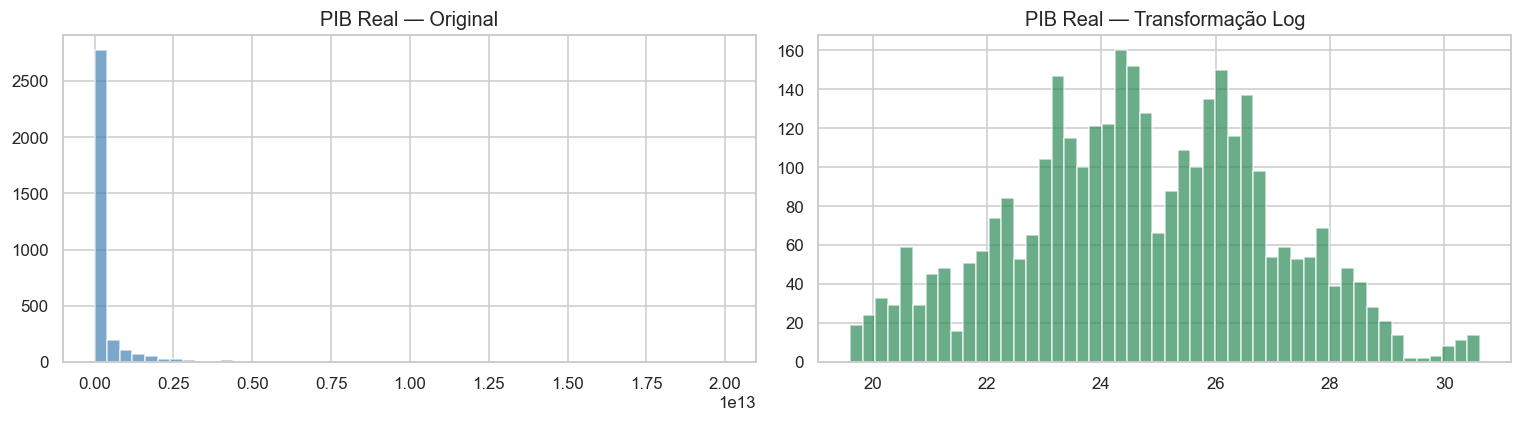

Skewness PIB original: 7.901
Skewness PIB log: -0.030


In [20]:
# Variáveis com forte assimetria positiva se beneficiam de transformação log.
# Isso aproxima a distribuição da normal, melhora correlações lineares
# e reduz o efeito desproporcional de outliers nos algoritmos.

# Usamos log(x + 1) para tratar zeros (log de 0 é indefinido)
cols_log = [
    'real_gdp_constant_2015_usd',
    'total_population',
    'total_greenhouse_gas_emissions_kt_co2e',
    'official_development_assistance_usd'
]

for col in cols_log:
    # Garantir que não há negativos antes do log
    min_val = df_prep[col].min()
    offset = abs(min_val) + 1 if min_val <= 0 else 0
    df_prep[f'log_{col}'] = np.log1p(df_prep[col] + offset)

# Comparação visual: antes e depois da transformação log para PIB
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(df_prep['real_gdp_constant_2015_usd'], bins=50, color='steelblue', alpha=0.7)
axes[0].set_title('PIB Real — Original')
axes[1].hist(df_prep['log_real_gdp_constant_2015_usd'], bins=50, color='seagreen', alpha=0.7)
axes[1].set_title('PIB Real — Transformação Log')
plt.tight_layout()
plt.show()

# Verificar skewness antes e depois
print(f'Skewness PIB original: {df_prep["real_gdp_constant_2015_usd"].skew():.3f}')
print(f'Skewness PIB log: {df_prep["log_real_gdp_constant_2015_usd"].skew():.3f}')

### Observações

1. O Problema: Histograma Azul (Original)
- Quase todos os países do mundo estão "espremidos" na primeira barra, perto do zero.
- Como apenas os EUA e a China chegam perto desse valor, o gráfico fica vazio na maior parte, e o modelo de Machine Learning teria muita dificuldade em entender a diferença entre um país de 10 bilhões e um de 100 bilhões, já que ambos pareceriam "zero" perto dos gigantes.

2. A Solução: Histograma Verde (Transformação Log)
- A distribuição agora se assemelha muito mais a uma Distribuição Normal (em formato de sino).
- Os valores no eixo X (de 20 a 30) representam as potências. Por exemplo, um país no nível 23 e outro no 24 agora são comparáveis, permitindo que o algoritmo identifique padrões tanto em economias pequenas quanto em grandes.

### 6.5 Normalização e Padronização

In [21]:
# Definição do conjunto de features para ML
# Excluímos: identificadores (country_name, country_identifier),
# variáveis originais que foram transformadas (substituídas pelas log_),
# e variáveis redundantes (land_area e surface_area são muito correlacionadas)

features_ml = [
    'observation_year',
    'adaptive_capacity_index',
    'foreign_direct_investment_net_inflows_pct_gdp',
    'forest_area_pct_land_area',
    'renewable_energy_consumption_pct_final_energy_use',
    'natural_capital_dependency_index',
    'urban_population_pct_total_population',
    'readiness_index',
    'ecological_footprint_index',
    'co2_emissions_metric_tonnes_per_capita',
    'greenhouse_gas_emissions_metric_tonnes_per_capita',
    'average_temperature_celsius',
    'annual_precipitation_mm',
    'land_area_sq_km',
    'log_real_gdp_constant_2015_usd',
    'log_total_population',
    'log_total_greenhouse_gas_emissions_kt_co2e',
    'log_official_development_assistance_usd',
    'country_name_encoded'
]

df_ml = df_prep[features_ml + ['country_name']].copy()

print(f'Dataset para ML: {df_ml.shape[0]} linhas × {df_ml.shape[1]} colunas')
print(f'Nulos restantes: {df_ml.isnull().sum().sum()}')

Dataset para ML: 3354 linhas × 20 colunas
Nulos restantes: 0


In [22]:
# Aplicação de StandardScaler nas features numéricas
# 
# Escolha do StandardScaler (Z-score) em detrimento do MinMaxScaler:
# - O dataset contém outliers legítimos e distribuições não-uniformes.
# - O MinMaxScaler é sensível a outliers: um único extremo comprime todos os
#   demais valores em uma faixa estreita.
# - O StandardScaler é robusto: transforma para média 0 e desvio 1, preservando
#   a forma da distribuição e sendo menos afetado pelos extremos.
# - Indicado para SVM, regressão logística, PCA e redes neurais.
#
# Excluímos: country_name (categórico), country_name_encoded (será tratado
# como feature de identificação, não precisa de escala contínua).

cols_escalar = [c for c in features_ml if c != 'country_name_encoded']

scaler = StandardScaler()
df_scaled = df_ml.copy()
df_scaled[cols_escalar] = scaler.fit_transform(df_ml[cols_escalar])

print('StandardScaler aplicado com sucesso.')
print(f'\nVerificação — médias (devem ser ≈ 0):')
print(df_scaled[cols_escalar].mean().round(6).head(5).to_string())
print(f'\nVerificação — desvios padrão (devem ser ≈ 1):')
print(df_scaled[cols_escalar].std().round(6).head(5).to_string())

StandardScaler aplicado com sucesso.

Verificação — médias (devem ser ≈ 0):
observation_year                                     0.0000
adaptive_capacity_index                             -0.0000
foreign_direct_investment_net_inflows_pct_gdp        0.0000
forest_area_pct_land_area                            0.0000
renewable_energy_consumption_pct_final_energy_use   -0.0000

Verificação — desvios padrão (devem ser ≈ 1):
observation_year                                    1.0001
adaptive_capacity_index                             1.0001
foreign_direct_investment_net_inflows_pct_gdp       1.0001
forest_area_pct_land_area                           1.0001
renewable_energy_consumption_pct_final_energy_use   1.0001


### 6.6 Dataset Final Preparado

In [23]:
# Resumo do dataset final
print('='*60)
print('DATASET FINAL — RESUMO')
print('='*60)
print(f'Dimensões: {df_scaled.shape[0]} linhas × {df_scaled.shape[1]} colunas')
print(f'Nulos: {df_scaled.isnull().sum().sum()}')
print(f'Países cobertos: {df_scaled["country_name"].nunique()}')
print(f'Período: {df["observation_year"].min()} – {df["observation_year"].max()}')
print()
print('Colunas disponíveis:')
for c in df_scaled.columns:
    print(f'  • {c}')

DATASET FINAL — RESUMO
Dimensões: 3354 linhas × 20 colunas
Nulos: 0
Países cobertos: 129
Período: 1995 – 2020

Colunas disponíveis:
  • observation_year
  • adaptive_capacity_index
  • foreign_direct_investment_net_inflows_pct_gdp
  • forest_area_pct_land_area
  • renewable_energy_consumption_pct_final_energy_use
  • natural_capital_dependency_index
  • urban_population_pct_total_population
  • readiness_index
  • ecological_footprint_index
  • co2_emissions_metric_tonnes_per_capita
  • greenhouse_gas_emissions_metric_tonnes_per_capita
  • average_temperature_celsius
  • annual_precipitation_mm
  • land_area_sq_km
  • log_real_gdp_constant_2015_usd
  • log_total_population
  • log_total_greenhouse_gas_emissions_kt_co2e
  • log_official_development_assistance_usd
  • country_name_encoded
  • country_name


In [24]:
# Exportação do dataset preparado
df_scaled.to_csv('energy_economics_preparado.csv', index=False)
print('Dataset exportado: energy_economics_preparado.csv')

# Também exportamos a versão sem escala (com transformações, sem StandardScaler)
# para uso em modelos baseados em árvore (que não necessitam de normalização)
df_ml.to_csv('energy_economics_tratado.csv', index=False)
print('Dataset tratado (sem escala): energy_economics_tratado.csv')

Dataset exportado: energy_economics_preparado.csv
Dataset tratado (sem escala): energy_economics_tratado.csv


## 7. Dificuldades e Limitações

**Dificuldades técnicas encontradas:**

1. **Colunas numéricas armazenadas como string:** três variáveis (`foreign_direct_investment_net_inflows_pct_gdp`, `real_gdp_constant_2015_usd`, `natural_capital_dependency_index`) estavam tipadas como `object` no CSV, impossibilitando cálculos estatísticos diretos. A solução foi a conversão explícita com `pd.to_numeric(..., errors='coerce')`.

2. **Alta taxa de nulos em `official_development_assistance_usd`** (~20,6%): A interpretação correta dos nulos (ausência de recebimento, não dado faltante) exigiu análise contextual antes de escolher a estratégia de imputação.

3. **Dados de painel (longitudinal):** a estrutura país × ano significa que observações do mesmo país são correlacionadas entre si, o que viola a premissa de independência de muitos modelos. Estratégias como validação cruzada temporal ou modelos com efeitos fixos serão necessárias.

**Limitações identificadas:**

1. **Cobertura temporal desigual:** nem todos os países possuem dados para todos os anos, gerando um painel desbalanceado.

2. **Escopo de países:** os 129 países não abrangem a totalidade das nações do mundo, podendo introduzir viés de seleção.

3. **Multicolinearidade:** `adaptive_capacity_index` e `readiness_index` são altamente correlacionados (r > 0,90), o que pode prejudicar modelos lineares. Em modelos futuros, PCA ou seleção de features será recomendada.

4. **Relações não-lineares:** o coeficiente de Pearson captura apenas relações lineares; padrões mais complexos (como a curva de Kuznets ambiental) exigem métodos não-lineares.

## 8. Conclusão

Foram realizadas:

- **Análise exploratória completa:** estatísticas descritivas, distribuições, análise de correlação de Pearson, identificação de outliers, padrões temporais e geográficos;
- **Tratamento de dados:** conversão de tipos, imputação por mediana de grupo (país), preenchimento semântico de nulos com zero para ODA;
- **Engenharia de features:** transformação logarítmica para variáveis com forte assimetria positiva (PIB, população, emissões totais);
- **Codificação de variáveis categóricas:** Label Encoding para `country_name` (129 categorias);
- **Normalização:** StandardScaler aplicado ao conjunto de features numéricas, escolhido por sua robustez a outliers.

**Principais achados analíticos:**
- Existe forte correlação positiva entre CO₂ per capita, pegada ecológica e urbanização;
- Países tropicais (maior temperatura média) tendem a emitir menos, refletindo menor industrialização histórica;
- A capacidade adaptativa e o índice de prontidão climática são altamente colineares, representando na prática uma única dimensão latente;
- A evolução temporal das médias globais revela tendência de leve crescimento nas emissões per capita até meados dos anos 2000, seguida de estabilização.

**Condição final do dataset:**  
O dataset encontra-se completamente preparado para uso em modelos de aprendizado de máquina: sem valores nulos, variáveis categóricas codificadas, variáveis assimétricas transformadas e features numéricas padronizadas. Foram gerados dois arquivos de saída: um com StandardScaler (indicado para SVM, regressão e redes neurais) e outro sem escala (indicado para modelos baseados em árvore, como Random Forest e XGBoost).